In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from hypex import AATest
from hypex.dataset import (
    Dataset,
    ExperimentData,
    FeatureRole,
    TargetRole,
    TreatmentRole,
)
from hypex.utils import ExperimentDataEnum
from hypex.experiments import ParamsExperiment

/home/eric/.local/lib/python3.8/site-packages/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


In [4]:
from hypex.comparators import TTest
TTest(reliability=0.01, key="my_test")

Parameter,Value
grouping_role,Grouping(None)
target_roles,Target(None)
baseline_role,PreTarget()
reliability,0.01
compare_by,'groups'
key,'my_test'


In [18]:
n_rows = 10000
n = n_rows
df = pd.DataFrame({
    "treatment": np.random.choice([0, 1], size=n, p=[0.6, 0.4]),
    "feat_num_1": np.random.normal(loc=10, scale=3, size=n),
    "feat_num_2": np.random.normal(loc=-2, scale=1.5, size=n),
    "feat_cat": np.random.choice(["A", "B", "C"], size=n),
    "target": np.random.normal(loc=100, scale=10, size=n)
})

In [19]:
roles = {
    "treatment": TreatmentRole(),
    "feat_num_1": FeatureRole(),
    "feat_num_2": TargetRole(),
    "feat_cat": FeatureRole(str),
    "target": TargetRole(),
}

dataset = Dataset(
    roles=roles,
    data=df,
)

In [20]:
_exp = AATest(n_iterations=10, dry_test=True)
exp = _exp.experiment
# for executor in exp.executors:
#     print(executor)
exp

Experiment(executors=[ParamsExperiment(executors=[Experiment(executors=[NaDropper(target_roles=Target(None), how='any', key=''), AASplitter(control_size=0.5, random_state=None, sample_size=None, constant_key=True, save_groups=True, groups_sizes=None, key=''), Experiment(executors=[GroupSizes(compare_by='groups', grouping_role=AdditionalTreatment(None)), OnRoleExperiment(executors=[GroupDifference(compare_by='groups', grouping_role=AdditionalTreatment(None), target_roles=Target(None)), TTest(grouping_role=AdditionalTreatment(None), target_roles=Target(None), baseline_role=PreTarget(), reliability=0.05, compare_by='groups', key=''), KSTest(grouping_role=AdditionalTreatment(None), target_roles=Target(None), baseline_role=PreTarget(), reliability=0.05, compare_by='groups', key=''), Chi2Test(grouping_role=AdditionalTreatment(None), target_roles=Target(None), baseline_role=PreTarget(), reliability=0.05, compare_by='groups', key='')], role=[Target(None), Feature()], transformer=False, key=''), OneAAStatAnalyzer(key='')], transformer=False, key='')], transformer=True, key='')], reporter=<hypex.reporters.abstract.DatasetReporter object at 0x7f2828577250>, params={<class 'hypex.splitters.aa.AASplitter'>: {'random_state': range(0, 10), 'control_size': [0.5], 'sample_size': [None], 'groups_sizes': [None]}, <class 'hypex.comparators.abstract.GroupsComparator'>: {'grouping_role': [AdditionalTreatment(None)], 'space': [<SpaceEnum.additional: 'additional'>]}}, transformer=False, key=''), AAScoreAnalyzer(alpha=0.05, key=''), AADryTestAnalyzer(alpha=0.05, key='')], transformer=False, key='AATest')

In [21]:
exp_data = ExperimentData(dataset)
result = exp.execute(exp_data)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:03<00:00,  2.87it/s]


In [22]:
exp_data.analysis_tables

{'ParamsExperiment┴┴AATest':         splitter_id  feat_num_1┆stats GroupDifference mean┆feat_num_1 control  feat_num_1┆stats GroupDifference mean┆feat_num_1 test_1  feat_num_2┆stats GroupDifference mean┆feat_num_2 control  feat_num_2┆stats GroupDifference mean┆feat_num_2 test_1  target┆stats GroupDifference mean┆target control  target┆stats GroupDifference mean┆target test_1  feat_num_1 GroupDifference control mean test_1  feat_num_1 GroupDifference test mean test_1  feat_num_1 GroupDifference difference test_1  ...  feat_num_1 KSTest pass test_1  feat_num_2 KSTest p-value test_1  feat_num_2 KSTest pass test_1  target KSTest p-value test_1  target KSTest pass test_1  mean TTest p-value all  mean TTest pass all  mean KSTest p-value all  mean KSTest pass all  mean test score
 0  AASplitter┴rs 0┴                                                 10.018194                                                 9.891220                                                 -1.991413                       

In [17]:
exp_data.analysis_tables

{'ParamsExperiment┴┴AATest':         splitter_id  feat_num_1┆stats GroupDifference mean┆feat_num_1 control  feat_num_1┆stats GroupDifference mean┆feat_num_1 test_1  feat_num_2┆stats GroupDifference mean┆feat_num_2 control  feat_num_2┆stats GroupDifference mean┆feat_num_2 test_1  target┆stats GroupDifference mean┆target control  target┆stats GroupDifference mean┆target test_1  feat_num_1 GroupDifference control mean test_1  feat_num_1 GroupDifference test mean test_1  feat_num_1 GroupDifference difference test_1  ...  feat_num_1 KSTest pass test_1  feat_num_2 KSTest p-value test_1  feat_num_2 KSTest pass test_1  target KSTest p-value test_1  target KSTest pass test_1  mean TTest p-value all  mean TTest pass all  mean KSTest p-value all  mean KSTest pass all  mean test score
 0  AASplitter┴rs 0┴                                                  9.983241                                                10.042147                                                 -2.002682                       

In [ ]:
exp_data.analysis_tables['AADryTestAnalyzer┴┴AATest'].loc['feat_num_2', 'statistic']

,0
0,0.211324


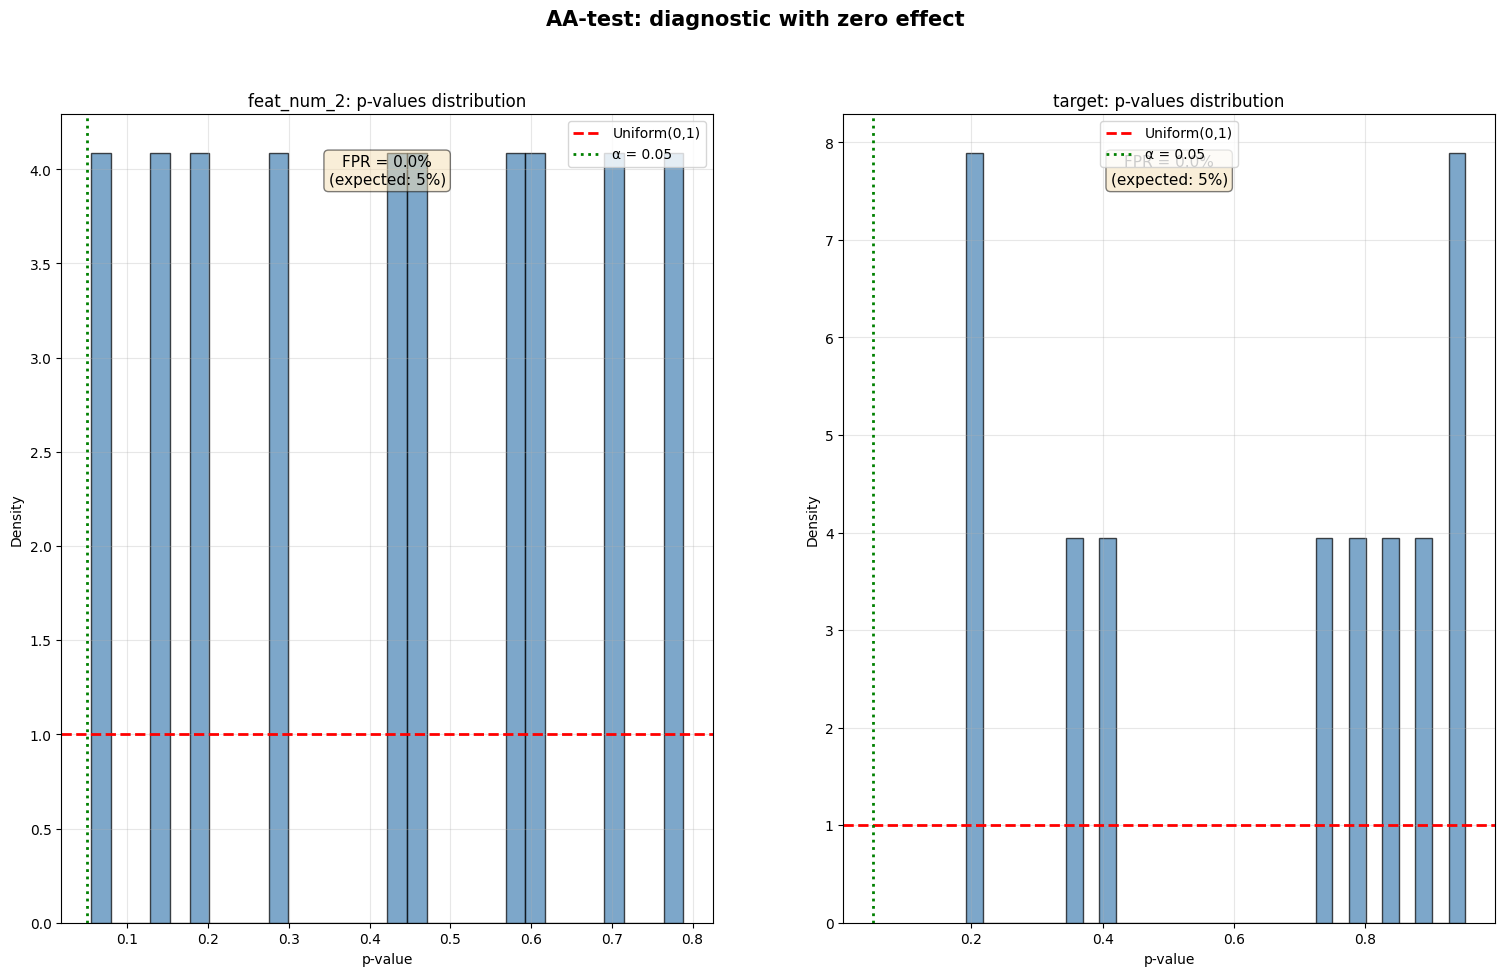

In [23]:
fig = exp_data.variables['AADryTestAnalyzer┴┴AATest']['AATest']
fig.set_size_inches(18.5, 10.5, forward=True)
fig
# plt.tight_layout()
# plt.show()

In [11]:
param_id = exp_data.get_one_id(
    ParamsExperiment,
    space=ExperimentDataEnum.analysis_tables
)

In [12]:
exp_data.analysis_tables[param_id].columns

Index(['splitter_id',
       'feat_num_1┆stats GroupDifference mean┆feat_num_1 control',
       'feat_num_1┆stats GroupDifference mean┆feat_num_1 test_1',
       'feat_num_2┆stats GroupDifference mean┆feat_num_2 control',
       'feat_num_2┆stats GroupDifference mean┆feat_num_2 test_1',
       'target┆stats GroupDifference mean┆target control',
       'target┆stats GroupDifference mean┆target test_1',
       'feat_num_1 GroupDifference control mean test_1',
       'feat_num_1 GroupDifference test mean test_1',
       'feat_num_1 GroupDifference difference test_1',
       'feat_num_1 GroupDifference difference % test_1',
       'feat_num_2 GroupDifference control mean test_1',
       'feat_num_2 GroupDifference test mean test_1',
       'feat_num_2 GroupDifference difference test_1',
       'feat_num_2 GroupDifference difference % test_1',
       'target GroupDifference control mean test_1',
       'target GroupDifference test mean test_1',
       'target GroupDifference difference test

In [ ]:
cols = [col for col in exp_data.analysis_tables[param_id].columns if "TTest p-value" in col and "mean" not in col]
exp_data.analysis_tables[param_id][cols]

,feat_num_1 TTest p-value test_1,feat_num_2 TTest p-value test_1,target TTest p-value test_1
0,0.777271,0.277437,0.640932
1,0.671656,0.895272,0.713822
2,0.112781,0.516673,0.586318
3,0.571295,0.761042,0.263018
4,0.360725,0.308912,0.506655
5,0.954059,0.497047,0.853569
6,0.991584,0.847562,0.259975
7,0.787070,0.598503,0.239620
8,0.670239,0.081811,0.546503
9,0.996113,0.554662,0.253444


In [15]:
exp_data.field_search(TargetRole()) in "target"


TypeError: 'in <string>' requires string as left operand, not list